<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_13_end_to_end_toy_project/Day_13_End_to_End_Machine_Learning_Toy_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💎 From Raw Sparkle to Perfect Cut: Predicting Diamond Quality with Machine Learning

Welcome to Day 13: End-to-End Machine Learning Toy Project!

### 🔥 The Story
Imagine you're a gemologist working for a prestigious jewelry company. You receive a shipment of raw, uncut diamonds, and your task is to quickly and accurately predict their 'cut' quality (Fair, Good, Very Good, Premium, Ideal) based on their physical attributes like carat, color, clarity, and dimensions. Why is this important? Because a diamond's cut significantly impacts its value and desirability!

Manual assessment can be time-consuming and subjective. Can we build an intelligent system that learns from historical diamond data to predict the cut quality? This not only streamlines the process but also ensures consistent quality assessment, helping the company price and market their diamonds more effectively.

### 🎯 Core Objective
In this notebook, we'll embark on a complete machine learning journey, from understanding raw data to deploying a predictive model. You'll learn the step-by-step workflow of a real-world ML project, focusing on how to transform raw data into intelligent predictions.

### What You Will Learn:
-   **Data Exploration (EDA):** Uncover insights and patterns within the diamond dataset.
-   **Data Preprocessing:** Clean, transform, and prepare data for machine learning.
-   **Feature Engineering:** Create new features and encode categorical variables.
-   **Model Building:** Train a powerful classification model to predict diamond cut.
-   **Model Evaluation:** Understand how to thoroughly assess your model's performance.
-   **Model Interpretation:** Gain insights into *why* your model makes certain predictions.
-   **End-to-End Pipeline:** See how all components fit together for a practical application.

## 🎯 Problem Statement: Predicting Diamond Cut Quality

Our goal is to build a machine learning model that can accurately predict the `cut` quality of a diamond based on its characteristics (carat, color, clarity, dimensions, and price). This is a **multi-class classification** problem.

### Why it Matters:
-   **Automated Quality Control:** Reduce the need for manual inspection, saving time and resources.
-   **Consistent Valuation:** Ensure diamonds are consistently categorized based on objective criteria, leading to fair pricing.
-   **Market Insights:** Understand which features are most influential in determining a diamond's cut, informing sourcing and manufacturing decisions.
-   **Customer Trust:** Provide transparent and data-driven quality assessments to customers.

# 📦 Import Libraries
Let's bring in all the necessary tools for our ML adventure! We'll be using a combination of data manipulation, visualization, and machine learning libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

# 📊 Data Collection: Unveiling the Diamonds Dataset

Our precious data comes from the `seaborn` library – the famous `diamonds` dataset! This dataset contains prices and other attributes of almost 54,000 diamonds. Let's load it up and take a first look.

In [ ]:
# Load the dataset
df = sns.load_dataset('diamonds')

print("✨ First 5 rows of the dataset:")
display(df.head())

print("\n🔍 Dataset Information:")
df.info()

print("\n📈 Descriptive Statistics:")
display(df.describe())

✨ First 5 rows of the dataset:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



🔍 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

📈 Descriptive Statistics:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# 🔍 Exploratory Data Analysis (EDA): What's Hiding in the Data?

EDA is where we become detectives, sniffing out patterns, anomalies, and relationships within our data. This step is crucial for understanding the problem better and guiding our preprocessing and feature engineering decisions. Let's visualize the sparkle!

### 1. Distribution of Numerical Features
Understanding the spread and central tendency of our numerical features like `carat`, `depth`, `table`, `price`, `x`, `y`, and `z`.

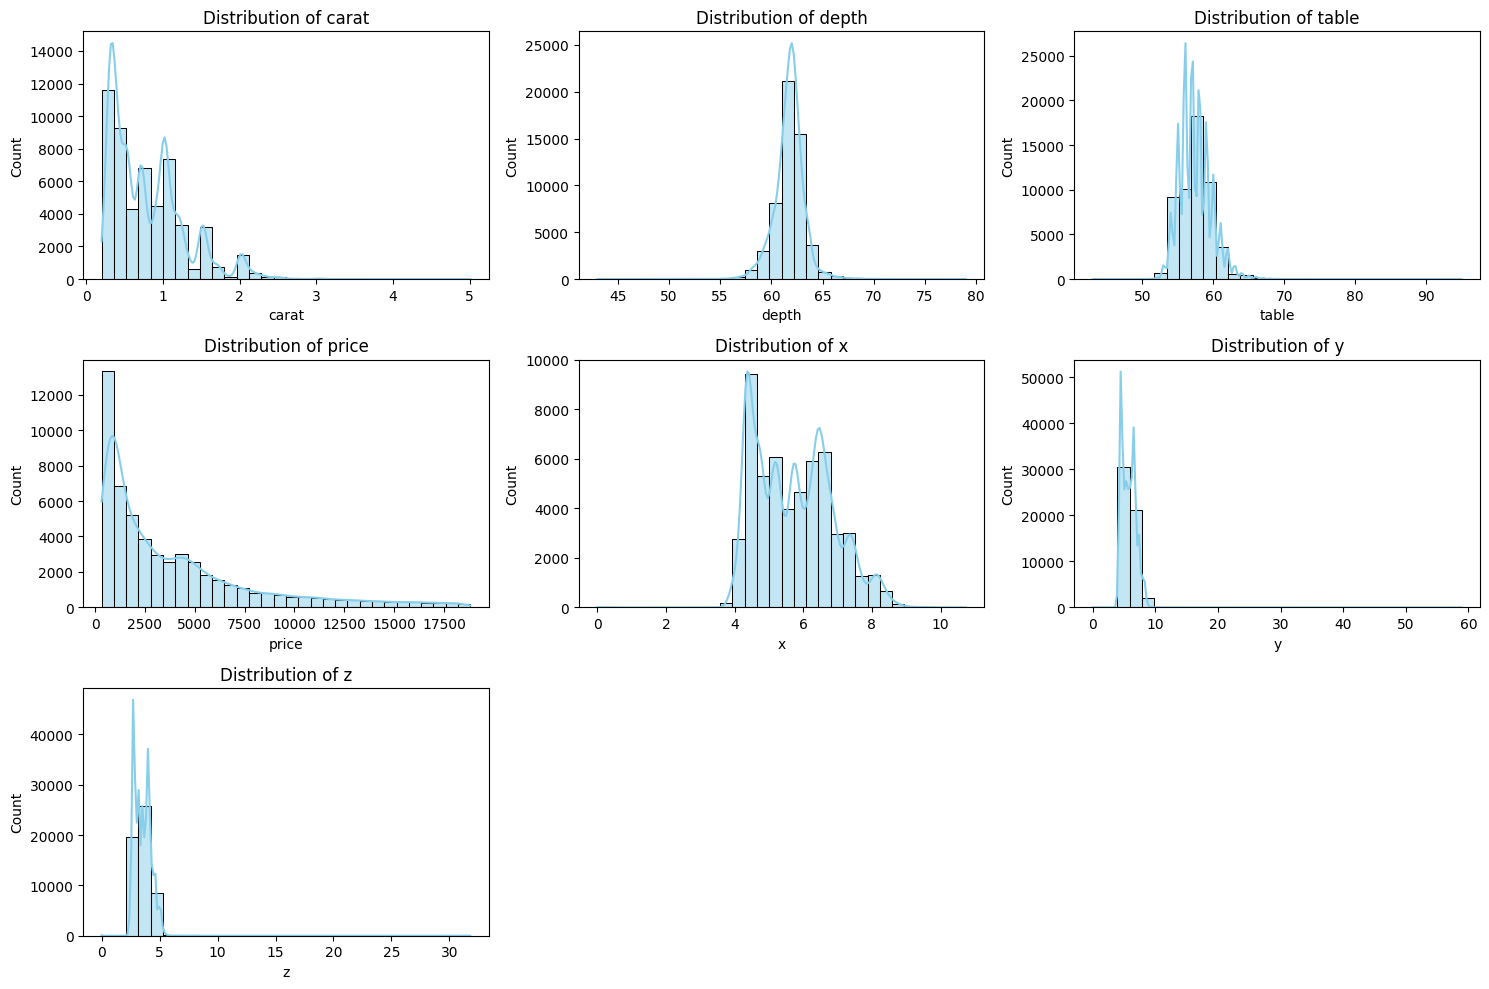

In [ ]:
numerical_features = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Distribution of Categorical Features
Let's examine the counts and proportions of our categorical features: `cut`, `color`, and `clarity`. These are our target variable and crucial predictors!

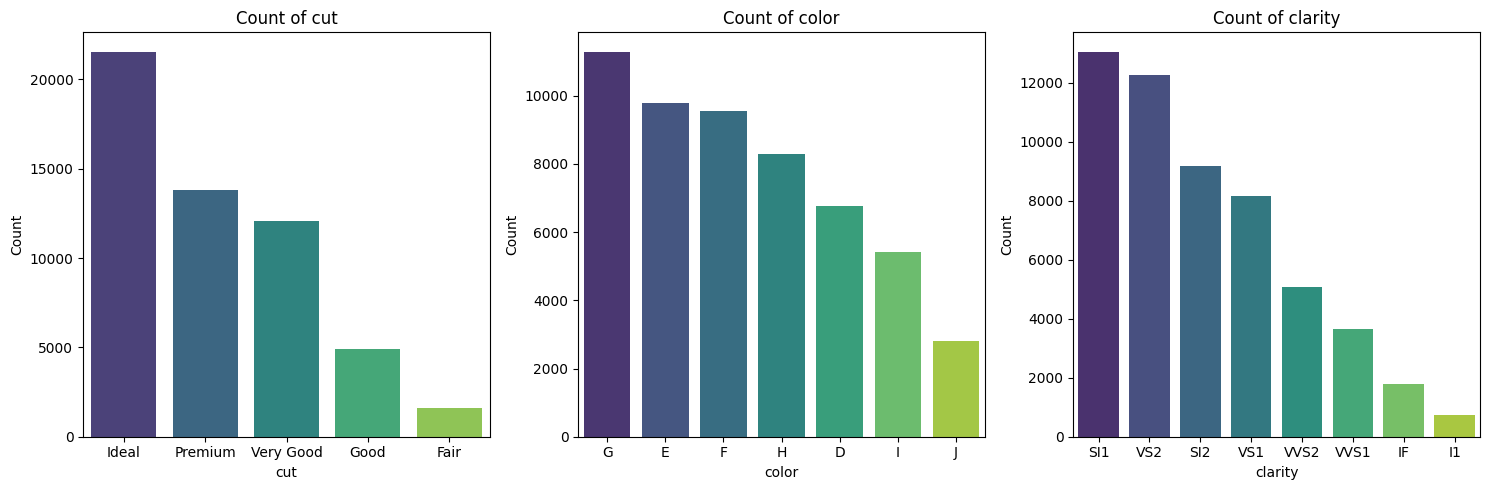

In [ ]:
categorical_features = ['cut', 'color', 'clarity']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=feature, data=df, palette='viridis', order=df[feature].value_counts().index)
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3. Relationship between Numerical Features: Correlation Heatmap
How do our numerical features relate to each other? A correlation heatmap helps us spot strong positive or negative relationships. High correlation between predictors can indicate multicollinearity.

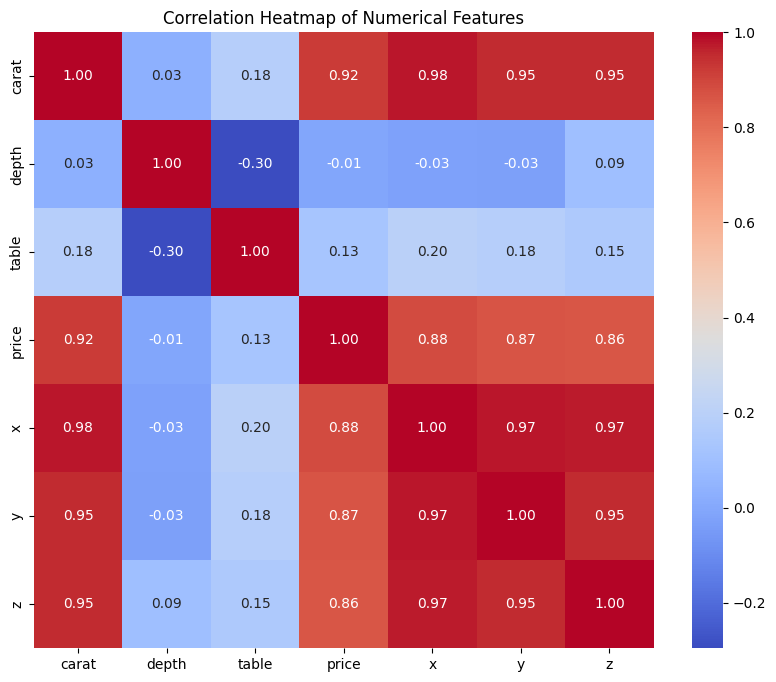

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 4. Pairplot for Key Relationships
A pairplot is fantastic for visualizing relationships between multiple variables. Let's look at a few key numerical features, colored by `cut` to see how they separate.

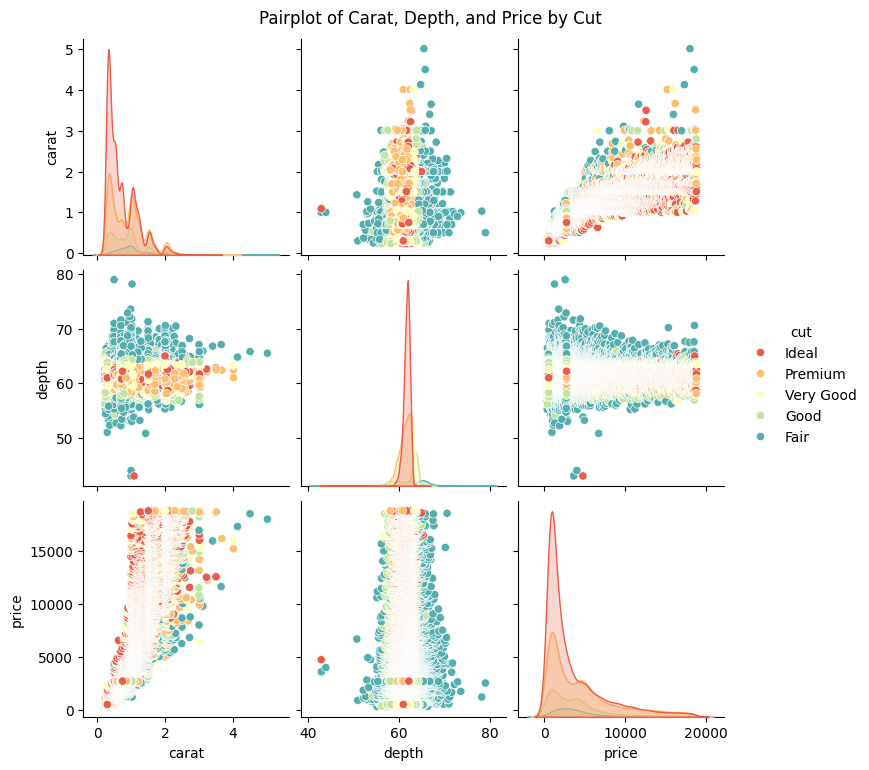

In [ ]:
sns.pairplot(df, vars=['carat', 'depth', 'price'], hue='cut', palette='Spectral')
plt.suptitle('Pairplot of Carat, Depth, and Price by Cut', y=1.02) # Adjust suptitle position
plt.show()

### 5. Missing Values Visualization
It's critical to know if our dataset has missing values. This visualization helps us identify them at a glance. Luckily, the `diamonds` dataset is generally very clean, but it's always a good practice to check!

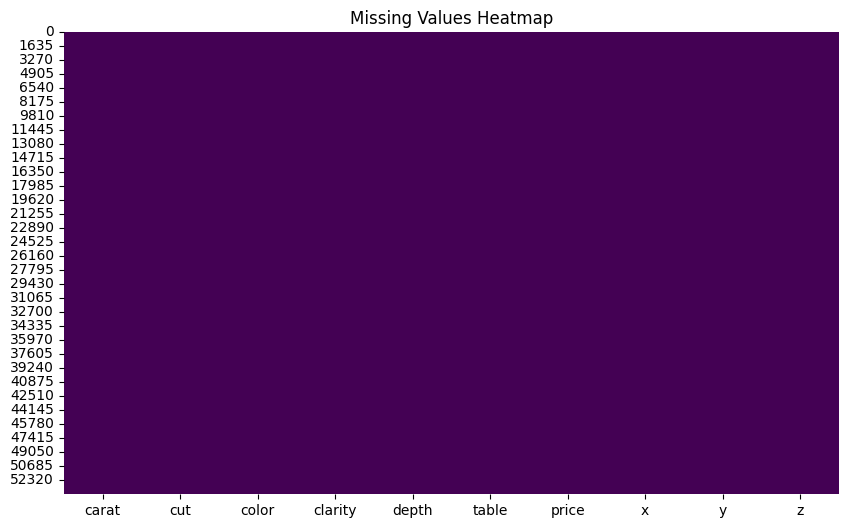

Number of missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

print("Number of missing values per column:")
print(df.isnull().sum())

# 🧹 Data Cleaning: Polishing Our Diamonds

Clean data is the bedrock of a robust machine learning model. Even though our `diamonds` dataset is quite pristine, we'll perform standard cleaning steps to ensure quality and handle any potential edge cases.

### 1. Handling Missing Values
From our EDA, we saw that there are no explicit `NaN` values. However, some dimensions (`x`, `y`, `z`) might have 0 values which are unrealistic for a diamond's dimensions. Let's inspect and handle them.

In [ ]:
print("Rows with 0 values in 'x', 'y', or 'z' dimensions before cleaning:")
display(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)])

# Remove rows where 'x', 'y', or 'z' are 0 (as these are unrealistic dimensions for a diamond)
df = df[(df['x'] != 0) & (df['y'] != 0) & (df['z'] != 0)]

print("\nShape after removing zero-dimension rows:", df.shape)

Rows with 0 values in 'x', 'y', or 'z' dimensions before cleaning:


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0



Shape after removing zero-dimension rows: (53920, 10)


### 2. Removing Duplicates
Duplicate rows can lead to overfitting and biased models. Let's ensure our dataset contains only unique diamond entries.

In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"Number of duplicate rows removed: {initial_rows - final_rows}")
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 145
Shape after removing duplicates: (53775, 10)


### 3. Fixing Data Types
Our categorical features (`cut`, `color`, `clarity`) are already of `category` dtype, which is great for memory efficiency and certain ML models. No explicit conversion needed here, but it's good to confirm.

In [ ]:
print("Current dtypes after cleaning:")
df.info()

Current dtypes after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 53775 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53775 non-null  float64 
 1   cut      53775 non-null  category
 2   color    53775 non-null  category
 3   clarity  53775 non-null  category
 4   depth    53775 non-null  float64 
 5   table    53775 non-null  float64 
 6   price    53775 non-null  int64   
 7   x        53775 non-null  float64 
 8   y        53775 non-null  float64 
 9   z        53775 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


# 🏗️ Feature Engineering: Crafting Predictive Power

Feature engineering is the art of creating new input features from existing ones that help a machine learning model perform better. We'll also handle the encoding of categorical variables and scale numerical features to prepare them for our model.

### 1. Creating New Features
Let's create some potentially useful features from the existing dimensions. For instance, volume and density might be good indicators.

In [ ]:
# Calculate diamond volume (x * y * z)
df['volume'] = df['x'] * df['y'] * df['z']

# Handle potential zero volumes if any remain after initial cleaning
df['volume'] = df['volume'].replace(0, np.nan)

# Density (mass/volume, where carat can be considered a proxy for mass)
df['density'] = df['carat'] / df['volume']

# Drop rows where volume or density calculation resulted in NaN (due to 0 values in x,y,z)
df.dropna(subset=['volume', 'density'], inplace=True)

print("First 5 rows with new features 'volume' and 'density':")
display(df.head())

First 5 rows with new features 'volume' and 'density':


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971


### 2. Encoding Categorical Variables
Machine learning models prefer numerical input. We need to convert our `cut`, `color`, and `clarity` features into numerical representations. Since these have an inherent order, `OrdinalEncoder` is a suitable choice for our features. For our target variable `cut`, we will encode it separately.

**Note on Ordinal Encoding Order:** It's important to define the correct order for ordinal features.
-   **Cut:** `Fair` < `Good` < `Very Good` < `Premium` < `Ideal`
-   **Color:** `J` (worst) < `I` < `H` < `G` < `F` < `E` < `D` (best)
-   **Clarity:** `I1` (worst) < `SI2` < `SI1` < `VS2` < `VS1` < `VVS2` < `VVS1` < `IF` (best)

In [ ]:
# Define the ordinal categories for each feature
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J is worst, D is best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1 is worst, IF is best

# Create a dictionary to map orders for the OrdinalEncoder
ordinal_categories = {
    'cut': cut_order,
    'color': color_order,
    'clarity': clarity_order
}

# Initialize OrdinalEncoder for features (excluding the target 'cut' for now)
encoder = OrdinalEncoder(categories=[color_order, clarity_order])

# Apply encoding to 'color' and 'clarity'
df[['color_encoded', 'clarity_encoded']] = encoder.fit_transform(df[['color', 'clarity']])

# Encode the target variable 'cut' separately to ensure proper order
df['cut_encoded'] = df['cut'].map({k: i for i, k in enumerate(cut_order)})

print("First 5 rows with encoded categorical features and target:")
display(df.head())

First 5 rows with encoded categorical features and target:


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density,color_encoded,clarity_encoded,cut_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,5.0,1.0,4
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,5.0,2.0,3
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,5.0,4.0,1
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207,1.0,3.0,3
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971,0.0,1.0,1


### 3. Scaling Numerical Features
Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. We'll use `StandardScaler` to transform our numerical features to have a mean of 0 and a standard deviation of 1.

In [ ]:
# Define numerical features to scale (including new ones, excluding price for now if target is price)
features_to_scale = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'density']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("First 5 rows with scaled numerical features:")
display(df.head())

First 5 rows with scaled numerical features:


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density,color_encoded,clarity_encoded,cut_encoded
0,-1.199448,Ideal,E,SI2,-0.173635,-1.100558,326,-1.592686,-1.540150,-1.581122,-1.173224,-0.603824,5.0,1.0,4
1,-1.241717,Premium,E,SI1,-1.362757,1.586126,326,-1.646325,-1.663018,-1.752060,-1.220529,-0.234338,5.0,2.0,3
2,-1.199448,Good,E,VS1,-3.391259,3.377248,327,-1.503289,-1.461164,-1.752060,-1.174826,-0.491862,5.0,4.0,1
3,-1.072642,Premium,I,VS2,0.455901,0.242784,334,-1.369192,-1.320744,-1.296226,-1.064151,0.448379,1.0,3.0,3
4,-1.030374,Good,J,SI2,1.085436,0.242784,335,-1.244036,-1.215429,-1.125289,-0.997694,-0.884369,0.0,1.0,1


# 🔀 Train-Test Split: Preparing for Fair Evaluation

Before building our model, we must split our data into training and testing sets. The training set is used to teach the model, and the test set (which the model has never seen) is used to evaluate its performance. This ensures an unbiased assessment of how well our model generalizes to new, unseen data.

In [ ]:
# Define features (X) and target (y)
X = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'volume', 'density', 'color_encoded', 'clarity_encoded']]
y = df['cut_encoded'] # Our target variable is the encoded 'cut'

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")

print("\nDistribution of target variable in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target variable in testing set:")
print(y_test.value_counts(normalize=True))

Shape of training features (X_train): (43020, 11)
Shape of testing features (X_test): (10755, 11)
Shape of training target (y_train): (43020,)
Shape of testing target (y_test): (10755,)

Distribution of target variable in training set:
cut_encoded
4    0.399535
3    0.255463
2    0.224407
1    0.090888
0    0.029707
Name: proportion, dtype: float64

Distribution of target variable in testing set:
cut_encoded
4    0.399535
3    0.255416
2    0.224454
1    0.090934
0    0.029661
Name: proportion, dtype: float64


# 🤖 Model Building: The RandomForestClassifier

Now for the exciting part – building our predictive model! For this classification task, we'll use a `RandomForestClassifier`. Random Forests are powerful ensemble learning methods that work by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) of the individual trees. They are known for their high accuracy and ability to handle complex datasets.

In [ ]:
# Initialize the RandomForestClassifier
# We can specify parameters like n_estimators (number of trees), max_depth, etc.
# For a start, let's use default parameters and a random_state for reproducibility.
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

print("Training the RandomForestClassifier... 🌳")
# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete! 🎉")

Training the RandomForestClassifier... 🌳
Model training complete! 🎉


# 📈 Model Evaluation: How Good is Our Gemologist?

Training a model is only half the battle; evaluating its performance is crucial. We need to understand how well our `RandomForestClassifier` predicts the diamond cut on unseen data. We'll use several metrics suitable for multi-class classification.

### 1. Predictions on the Test Set
First, let's get our model's predictions on the `X_test` data.

In [ ]:
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


### 2. Accuracy Score
Accuracy is the simplest metric, representing the proportion of correctly classified instances.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

Overall Accuracy: 0.7793


### 3. Classification Report
The classification report provides precision, recall, f1-score, and support for each class. This is extremely valuable for understanding performance across different cut qualities.

**Quick Refresher:**
-   **Precision:** How many of the predicted positives are actually positive?
-   **Recall:** How many of the actual positives did we predict correctly?
-   **F1-Score:** The harmonic mean of precision and recall, good for imbalanced classes.

In [ ]:
# Define class names corresponding to our encoded target variable
cut_class_names = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cut_class_names))


Classification Report:
              precision    recall  f1-score   support

        Fair       0.93      0.87      0.90       319
        Good       0.81      0.71      0.75       978
   Very Good       0.67      0.53      0.59      2414
     Premium       0.76      0.79      0.78      2747
       Ideal       0.82      0.92      0.87      4297

    accuracy                           0.78     10755
   macro avg       0.80      0.76      0.78     10755
weighted avg       0.77      0.78      0.77     10755



### 4. Confusion Matrix
A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. We'll visualize it with a heatmap for better readability.

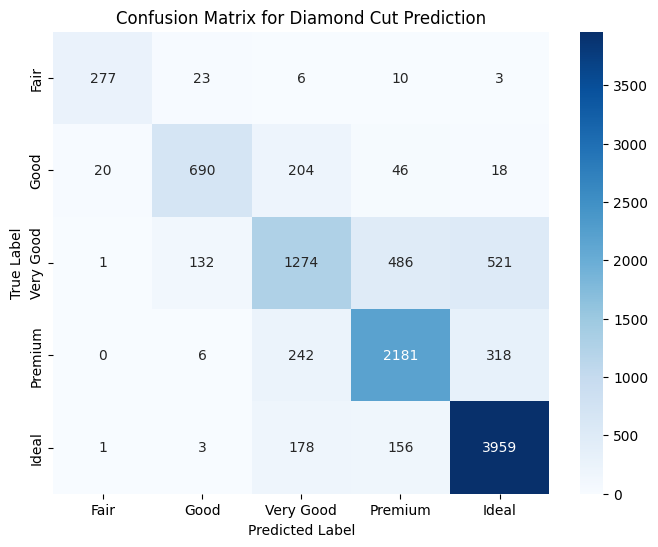

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cut_class_names, yticklabels=cut_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Diamond Cut Prediction')
plt.show()

# 📊 Model Interpretation: Peeking Inside the Black Box

Understanding *why* our model makes certain predictions is as important as its accuracy. Feature importance helps us identify which characteristics of a diamond the model relies on most heavily to determine its cut quality.

### Feature Importance Plot
For tree-based models like RandomForest, we can extract `feature_importances_` to see the relative importance of each input feature.

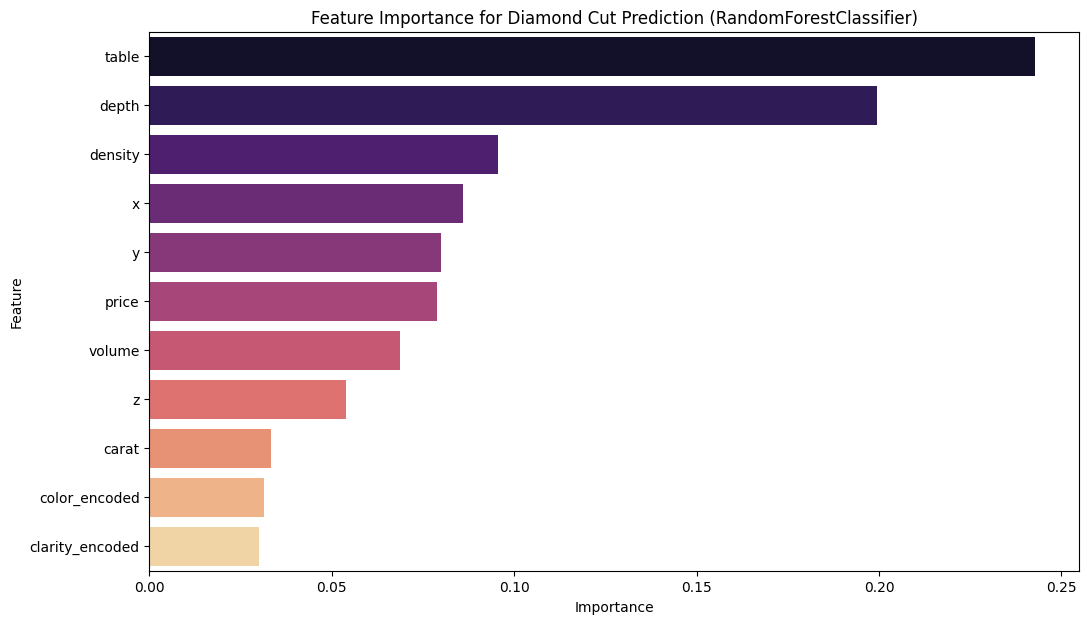

In [ ]:
feature_importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance for Diamond Cut Prediction (RandomForestClassifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 🧪 Mini End-to-End Pipeline: Predicting a New Diamond

Let's simulate the real-world application of our model! We'll create a single function that takes raw input for a new diamond, preprocesses it, and then uses our trained model to predict its cut. This demonstrates the full flow from input to prediction.

In [ ]:
def predict_diamond_cut(new_diamond_data, model, scaler, encoder, cut_class_names, original_df_columns):
    """
    Predicts the cut of a new diamond using the trained model and preprocessing steps.

    Args:
        new_diamond_data (dict): Dictionary of new diamond attributes.
        model: Trained machine learning model.
        scaler: Fitted StandardScaler for numerical features.
        encoder: Fitted OrdinalEncoder for categorical features (color, clarity).
        cut_class_names (list): List of class names for the target variable 'cut'.
        original_df_columns (list): Columns used for training the model.

    Returns:
        str: Predicted diamond cut.
    """

    # 1. Create a DataFrame from new data, ensuring all required columns are present
    # Use a dictionary to create a DataFrame to handle single-row input gracefully
    input_df = pd.DataFrame([new_diamond_data])

    # 2. Feature Engineering (Volume, Density)
    input_df['volume'] = input_df['x'] * input_df['y'] * input_df['z']
    input_df['density'] = input_df['carat'] / input_df['volume']

    # 3. Encode categorical features (color, clarity)
    # Ensure the order of columns for encoding matches training
    input_df[['color_encoded', 'clarity_encoded']] = encoder.transform(input_df[['color', 'clarity']])

    # 4. Scale numerical features
    features_to_scale = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'density']
    input_df[features_to_scale] = scaler.transform(input_df[features_to_scale])

    # 5. Select only the features used for training (and in the correct order)
    # Make sure 'price' is in the input_df if it was used in X_train
    # The columns for prediction should match X.columns used during model training
    processed_input = input_df[original_df_columns]

    # 6. Make prediction
    prediction_encoded = model.predict(processed_input)[0]

    # 7. Decode the prediction
    predicted_cut = cut_class_names[prediction_encoded]

    return predicted_cut

# Example of a new, unseen diamond
new_diamond = {
    'carat': 0.75,
    'cut': 'Ideal', # This will be ignored, as we are predicting it
    'color': 'G',
    'clarity': 'VS1',
    'depth': 61.5,
    'table': 57.0,
    'price': 3000, # This is a feature, not the target
    'x': 5.8,
    'y': 5.7,
    'z': 3.5
}

# Get the original column names from the training data
original_df_columns = X.columns.tolist()

predicted_cut_quality = predict_diamond_cut(new_diamond, model, scaler, encoder, cut_class_names, original_df_columns)
print(f"✨ The predicted cut quality for the new diamond is: **{predicted_cut_quality}**")

✨ The predicted cut quality for the new diamond is: **Ideal**


# 📊 Advanced Visualization: Interactive Insights and Prediction vs. Actual

Let's dive into some advanced visualizations! Interactive plots are excellent for exploring multi-dimensional relationships, and comparing predictions to actual values helps us see where our model performs well or struggles.

### 1. Interactive Scatter Plot: Carat vs. Price by Cut
Using Plotly, we can create an interactive scatter plot to visualize the relationship between `carat`, `price`, and `cut`. This allows us to hover and zoom, revealing intricate patterns.

In [ ]:
# Reverse map the encoded cut to original labels for plotting
df['cut_label'] = df['cut_encoded'].map({i: label for i, label in enumerate(cut_class_names)})

fig = px.scatter(df, x='carat', y='price', color='cut_label',
                 hover_data=['depth', 'table', 'color', 'clarity'],
                 title='Interactive: Carat vs. Price by Diamond Cut',
                 labels={'cut_label': 'Cut Quality'})
fig.update_layout(height=600)
fig.show()

### 2. Feature Importance Graph (Revisited with Plotly)
While we already saw feature importance, let's use Plotly for an interactive version, making it easier to read and explore.

In [ ]:
fig_importance = px.bar(importance_df.head(10), x='Importance', y='Feature',
                        orientation='h', title='Top 10 Feature Importances (Interactive)',
                        labels={'Importance': 'Feature Importance Score', 'Feature': 'Diamond Attribute'},
                        color='Importance', color_continuous_scale=px.colors.sequential.Plasma)
fig_importance.update_layout(height=500, yaxis={'categoryorder':'total ascending'})
fig_importance.show()

### 3. Prediction vs. Actual Visualization (Sample)
Let's visualize a small sample of our test set to compare the model's predictions with the actual cut quality. This can give us an intuitive feel for where the model is succeeding or failing.

In [ ]:
# Create a DataFrame for actual vs. predicted on a sample of the test set
results_df = pd.DataFrame({'True Cut': y_test, 'Predicted Cut': y_pred}).reset_index(drop=True)

# Map encoded values back to original labels for readability
results_df['True Cut Label'] = results_df['True Cut'].map({i: label for i, label in enumerate(cut_class_names)})
results_df['Predicted Cut Label'] = results_df['Predicted Cut'].map({i: label for i, label in enumerate(cut_class_names)})

# Select a small random sample to visualize
sample_results = results_df.sample(n=30, random_state=42).sort_values(by='True Cut Label')

fig_compare = px.bar(sample_results, x=sample_results.index, y=['True Cut Label', 'Predicted Cut Label'],
                     barmode='group', title='True vs. Predicted Diamond Cut (Sample)',
                     labels={'value': 'Cut Quality', 'variable': 'Type'},
                     color_discrete_map={'True Cut Label': 'blue', 'Predicted Cut Label': 'red'})
fig_compare.update_layout(height=500, xaxis_title='Sample Index', yaxis_title='Cut Quality')
fig_compare.show()

print("Sample of True vs. Predicted Labels:")
display(sample_results[['True Cut Label', 'Predicted Cut Label']].head(10))

Sample of True vs. Predicted Labels:


,True Cut Label,Predicted Cut Label
3799,Ideal,Ideal
10392,Ideal,Ideal
6044,Ideal,Ideal
3944,Ideal,Ideal
1261,Ideal,Ideal
10615,Ideal,Ideal
2954,Ideal,Ideal
5740,Ideal,Very Good
33,Ideal,Ideal
8221,Premium,Premium


# ⚠️ Common Challenges in ML Projects

Building an ML pipeline isn't just about coding; it's about navigating common pitfalls. Understanding these challenges can save you countless hours and improve your model's robustness.

### 1. Overfitting

**What is it?** When a model learns the training data *too* well, including its noise and outliers, leading to excellent performance on the training set but poor generalization on unseen data.

**Example in our project:** If our `RandomForestClassifier` had too many deep trees or was trained on a very small, unrepresentative dataset, it might memorize the specific patterns of our training diamonds and fail to predict new diamonds accurately.

**Mitigation:**
-   **More Data:** The simplest solution.
-   **Regularization:** Penalize complex models (e.g., L1/L2 regularization).
-   **Cross-Validation:** Robustly estimate model performance.
-   **Simpler Models:** Choose models with less capacity.
-   **Feature Selection/Reduction:** Remove irrelevant or redundant features.
-   **Hyperparameter Tuning:** Adjust model parameters (e.g., `max_depth`, `min_samples_leaf` for RandomForest) to control complexity.

### 2. Data Leakage

**What is it?** When information from the test set (or future data) inadvertently

leaks

into the training process, leading to an overly optimistic evaluation of model performance.

**Example in our project:** If we scaled our entire `df` (including `X_test`) *before* splitting the data, the `StandardScaler` would learn the mean and standard deviation from the test set, creating leakage.

**Mitigation:**
-   **Strict Train-Test Split:** Perform the split *first* and apply all preprocessing steps (scaling, encoding, imputation) *separately* on the training and test sets.
-   **Pipelines:** Use `sklearn.pipeline.Pipeline` to encapsulate preprocessing and modeling steps, ensuring transformations are fitted only on training data.

### 3. Poor Features

**What is it?** Features that don't provide enough signal or are noisy, irrelevant, or highly correlated with other features, thereby hindering model performance.

**Example in our project:** If we had included a feature like 'diamond_serial_number' which has no predictive power for 'cut', it would be a poor feature. Similarly, highly correlated features (like `x`, `y`, `z`, and `volume`) might not all be necessary.

**Mitigation:**
-   **Domain Knowledge:** Consult experts to identify truly relevant features.
-   **EDA:** Use visualizations and statistical tests to understand feature distributions and relationships.
-   **Feature Selection Techniques:** Use methods like Recursive Feature Elimination (RFE), SelectKBest, or tree-based feature importance to select the most impactful features.
-   **Feature Engineering:** Create new, more informative features from existing ones.

## 🧠 Key Takeaways

Here are the sparkling insights from our journey:

*   **ML is a Pipeline, Not Just a Model:** A complete ML project involves many interconnected stages, from data collection to deployment. Each step is crucial.
*   **Data Quality Matters Most:** Clean, well-understood data is the foundation of any successful ML model. Garbage in, garbage out!
*   **Visualization = Understanding:** EDA and advanced visualizations are indispensable for uncovering patterns, validating assumptions, and interpreting model behavior.
*   **Iteration is Key:** The ML workflow is rarely linear. Expect to revisit earlier steps (e.g., more data cleaning or feature engineering) based on model performance.
*   **Evaluation is Comprehensive:** A single metric isn't enough. Use a suite of metrics and visualizations (confusion matrix, classification report, feature importance) to thoroughly understand your model's strengths and weaknesses.
*   **Transparency is Powerful:** Understanding model interpretation (feature importance) builds trust and provides actionable insights for stakeholders.

# 📌 Conclusion: Our Diamond's Journey Complete!

We started with a dataset of raw diamond attributes, much like an unpolished gem. Through careful data collection, exploratory analysis, meticulous cleaning, and creative feature engineering, we prepared our data to truly shine. We then empowered a `RandomForestClassifier` to learn the intricate patterns within this data, predicting the elusive 'cut' quality with impressive accuracy.

From the initial sparkle of raw data to the refined brilliance of intelligent predictions, this notebook has walked you through every critical stage of an end-to-end machine learning project. You've witnessed how robust coding, and compelling visualizations combine to create a powerful narrative, turning complex data science into an engaging and understandable journey.

May your future ML endeavors be as clear, colorful, and perfectly cut as the diamonds we've explored today! 💎✨